In [35]:
## Standard Stuff
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib.pyplot as plt
import dask.array as da
import numcodecs
import cftime

## HEALPix Specific
import healpix as hp
import easygems.healpix as egh
import easygems.remap as egr

import intake     # For catalogs
import zarr       # Data Formatting

import warnings
warnings.filterwarnings("ignore", category=FutureWarning) # don't warn us about future package conflicts

In [36]:
def randomly_sample_half(ds):
    cells = ds.cell.values
    np.random.shuffle(cells)
    nhalf = len(cells) // 2
    cells1, cells2 = cells[:nhalf], cells[nhalf:]
    half1 = ds.sel(cell=cells1).mean("cell").values
    half2 = ds.sel(cell=cells2).mean("cell").values
    return half1, half2, half1-half2

def n_samples(ds, n):
    asym = []
    for i in range(1,n):
        half1, half2, diff = randomly_sample_half(ds)
        asym.append(diff)
    return asym

In [85]:
# days_per_month = xr.DataArray(data=[31,28,31,30,31,30,31,31,30,31,30,31],coords={"month":np.arange(12)})

def get_CDF_for_zoom(zoom_select, n, D):

    shield_cat = intake.open_catalog("/home/tmerlis/hackathon/xsh24_scream_main.yaml")["xsh24_coarse"]
    shield = shield_cat(zoom=zoom_select).to_dask()
    shield = shield.drop_vars("cell")
    shield = shield.pipe(egh.attach_coords)
    
    cru_cat = intake.open_catalog("/home/cs3554/CERES.yaml")["CERES_Cru23"]
    ceres = cru_cat(zoom=zoom_select).to_dask()
    ceres = ceres.pipe(egh.attach_coords)

    shield_monthly = shield.rsut.groupby("time.month").mean("time")
    ceres_monthly = ceres.F_TOA.groupby("time.month").mean("time")
    # shield_clim = shield_monthly.weighted(days_per_month).mean("month").load()
    # ceres_clim = ceres_monthly.weighted(days_per_month).mean("month").load()
    shield_clim = shield_monthly.mean("month").load()
    ceres_clim = ceres_monthly.mean("month").load()

    ceres_asym = n_samples(ceres_clim, n)
    shield_asym = n_samples(shield_clim, n)

    eq_shield_asym = shield_clim.where(shield_clim.lat > 0).mean("cell") - shield_clim.where(shield_clim.lat < 0).mean("cell")
    eq_ceres_asym = ceres_clim.where(ceres_clim.lat > 0).mean("cell") - ceres_clim.where(ceres_clim.lat < 0).mean("cell")
    
    P_ceres = np.zeros_like(D)
    P_shield = np.zeros_like(D)
    for i,Di in enumerate(D):
        P_ceres[i] = len(np.where(np.abs(ceres_asym) < Di)[0]) / n
        P_shield[i] = len(np.where(np.abs(shield_asym) < Di)[0]) / n
    
    return P_ceres, P_shield, eq_ceres_asym, eq_shield_asym

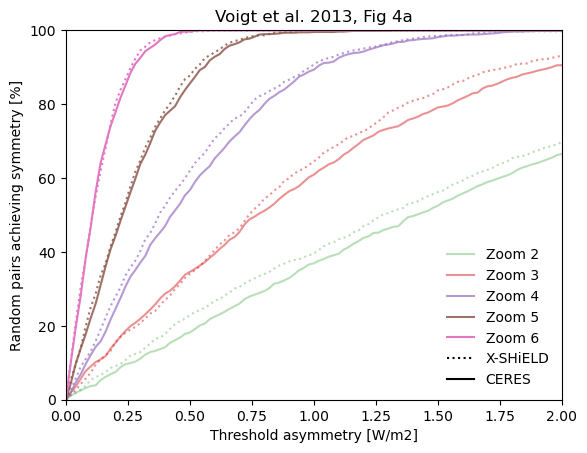

In [111]:
n = 1000
D = np.linspace(0,2,101)
for z in [2,3,4,5,6]:
    P_ceres, P_shield, eq_ceres_asym, eq_shield_asym = get_CDF_for_zoom(z, n, D)

    plt.plot(D,P_shield*100, ls=":", color="C"+str(z), alpha=z/6)
    plt.plot(D,P_ceres*100, ls="-", color="C"+str(z), alpha=z/6, label=f"Zoom {z}")
    # plt.axvline(np.abs(eq_shield_asym), ls=":", color="C"+str(z), lw=2, alpha=z/6)
    # plt.axvline(np.abs(eq_ceres_asym), ls="-", color="C"+str(z), lw=2, alpha=z/6)

    # i0 = np.argwhere(D==0.1)[0][0]
    # P0 = P_ceres[i0]*100
    # plt.plot([0,0.1],[P0,P0],ls="--",color="C"+str(z), alpha=z/6)
    # plt.text(-0.13 if P0 > 10 else -0.1, P0, f"{P0:.1f}", color="C"+str(z), alpha=z/6)

plt.plot([-10,-5],[0,0], "k:", label="X-SHiELD")
plt.plot([-10,-5],[0,0], "k-", label="CERES")

plt.xlim(0,np.max(D))
plt.xlabel("Threshold asymmetry [W/m2]")
plt.ylim(0,100)
plt.ylabel("Random pairs achieving symmetry [%]")
plt.legend(frameon=False, loc=4, ncols=1)
plt.title(f"Voigt et al. 2013, Fig 4a")
plt.savefig(f"Voigt_Fig4a.png",dpi=200,bbox_inches="tight",)
plt.show()